# 6. Fluctuation statistics

In [1]:
import numpy as np
import pandas as pd
from TracyWidom import TracyWidom
import os

from fluctuation_functions import compute_rescaled_phases_at_index, normalized_tw_pdf

In [2]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.4}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 1, "KPZ": 0.96}} # anomalous scaling, only for columnar noise
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

In [6]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/100, "KPZ": 1/10}, "Columnar": {"EW": 1/1500, "KPZ": 1/80}}

## Dataframe computations

In [7]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        beta = beta_dict[typenoise][delta_to_label[deltaname]]
        z = z_dict[typenoise][delta_to_label[deltaname]]

        ## AVERAGE FLUCTUATION STATISTICS PER (K, L, T) ##
        # group by K, L, T and compute fluctuation statistics for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            
            # if K_val not in Ks or T_val != T or L_val != L:
            #     continue
            
            t_cross = tx[typenoise][delta_to_label[deltaname]] * (L_val ** z)
            
            per_seed_varphis = []
            for _, row in group.iterrows():
                t = np.asarray(row["t"])
                phases = np.asarray(row["phases"])

                t0_idx = int(np.argmin(np.abs(t - 50)))-2 # optional, where to start.

                for ti_idx in range(t0_idx + 1, len(t)):
                    if t[ti_idx] < t_cross:
                        v = compute_rescaled_phases_at_index(phases, t, t0_idx, ti_idx, beta=beta)
                        per_seed_varphis.append(v)

            varphis_full = np.ravel(per_seed_varphis)
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "varphis_full": varphis_full,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [8]:
avg_df_path = "../Simulations_1D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "varphis_full"] = new_avg["varphis_full"]

avg_df.to_pickle(avg_df_path)

## Inspection of the computed quantities

In [9]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

%load_ext autoreload
%autoreload 2

from fluctuation_functions import plot_fluctuations_pdf

In [10]:
avg_df_path = "../Simulations_1D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

In [12]:
L = 1000
T = 20000
Ks = [1, 40]

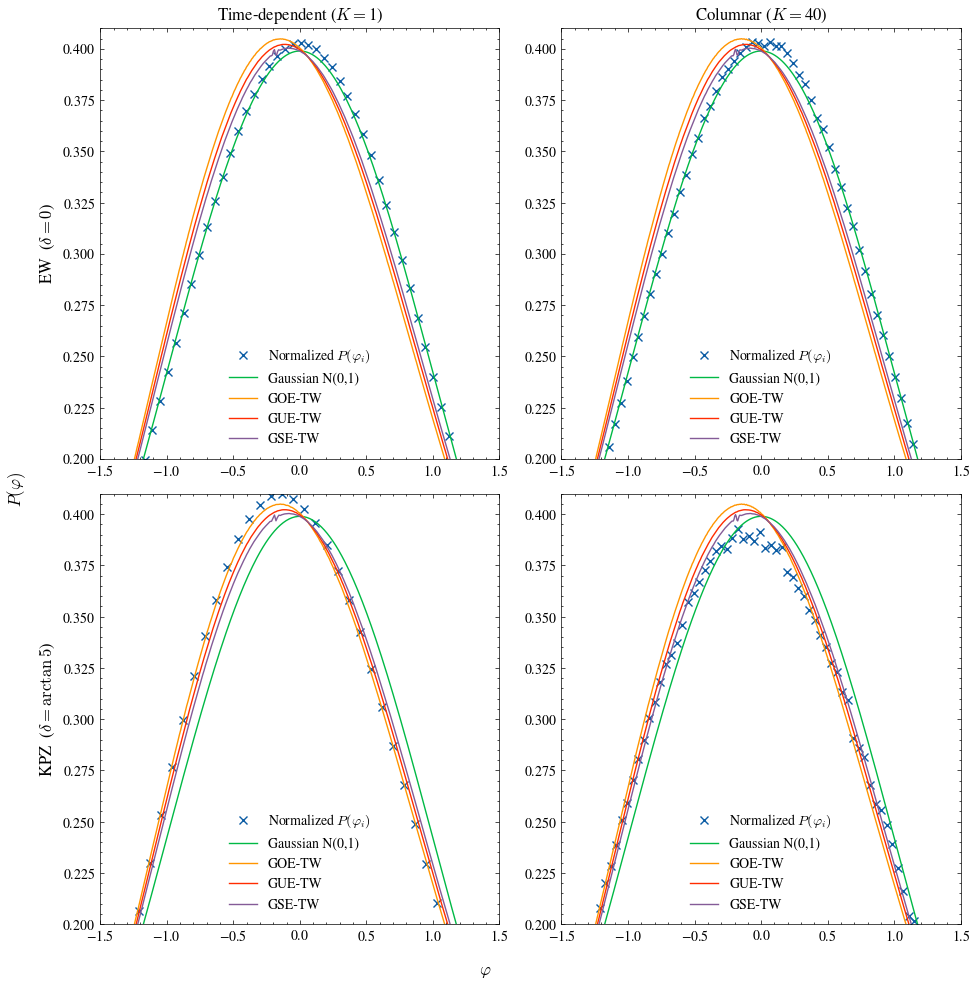

In [15]:
plot_fluctuations_pdf(avg_df, L, T, tx, Ks)

WHY DO THEY USE MUCH HIGHER COUPLINGS? (Columnar, delta = 0 -> K = 110)